In [2]:
!pip install qiskit qiskit-aer


# Quantum Phase Estimation (QPE) using Qiskit 2.x

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

def qpe_circuit(num_count_qubits, unitary, theta):
    """
    Constructs the Quantum Phase Estimation (QPE) circuit.
    num_count_qubits: number of counting qubits
    unitary: unitary gate (to apply controlled operations)
    theta: phase parameter (for U gate)
    """
    qc = QuantumCircuit(num_count_qubits + 1, num_count_qubits)

    # Step 1: Apply Hadamard gates on counting qubits
    qc.h(range(num_count_qubits))

    # Step 2: Prepare eigenstate (|1>) for the target qubit
    qc.x(num_count_qubits)

    # Step 3: Apply controlled unitary operations
    for qubit in range(num_count_qubits):
        qc.cp(2 * np.pi * theta * (2 ** qubit), qubit, num_count_qubits)

    # Step 4: Apply inverse QFT to counting qubits
    inverse_qft(qc, num_count_qubits)

    # Step 5: Measure counting qubits
    qc.measure(range(num_count_qubits), range(num_count_qubits))

    return qc


def inverse_qft(qc, n):
    """Apply the inverse Quantum Fourier Transform on n qubits."""
    for qubit in range(n // 2):
        qc.swap(qubit, n - qubit - 1)
    for j in range(n):
        for k in range(j):
            qc.cp(-np.pi / 2 ** (j - k), k, j)
        qc.h(j)
    return qc


def run_qpe(num_count_qubits=3, theta=0.125):
    """Executes the QPE circuit and visualizes the phase estimation result."""
    simulator = AerSimulator()
    qc = qpe_circuit(num_count_qubits, "U", theta)
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit, shots=2048).result()
    counts = result.get_counts()
    plot_histogram(counts)
    plt.show()
    print(qc.draw(output='text'))


if __name__ == "__main__":
    num_count_qubits = 3
    theta = 0.125  # phase value (1/8)
    print(f"Running Quantum Phase Estimation with {num_count_qubits} counting qubits and phase {theta}")
    run_qpe(num_count_qubits, theta)

Running Quantum Phase Estimation with 3 counting qubits and phase 0.125
     ┌───┐                            ┌───┐                                   »
q_0: ┤ H ├─■────────────────────────X─┤ H ├─■──────────────■──────────────────»
     ├───┤ │                        │ └───┘ │P(-π/2) ┌───┐ │                  »
q_1: ┤ H ├─┼────────■───────────────┼───────■────────┤ H ├─┼─────────■────────»
     ├───┤ │        │               │                └───┘ │P(-π/4)  │P(-π/2) »
q_2: ┤ H ├─┼────────┼────────■──────X──────────────────────■─────────■────────»
     ├───┤ │P(π/4)  │P(π/2)  │P(π)                                            »
q_3: ┤ X ├─■────────■────────■────────────────────────────────────────────────»
     └───┘                                                                    »
c: 3/═════════════════════════════════════════════════════════════════════════»
                                                                              »
«     ┌─┐           
«q_0: ┤M├───────────
«     

=== 🧩 Task 1 — Change the Phase Value ===

Phase θ = 0.25


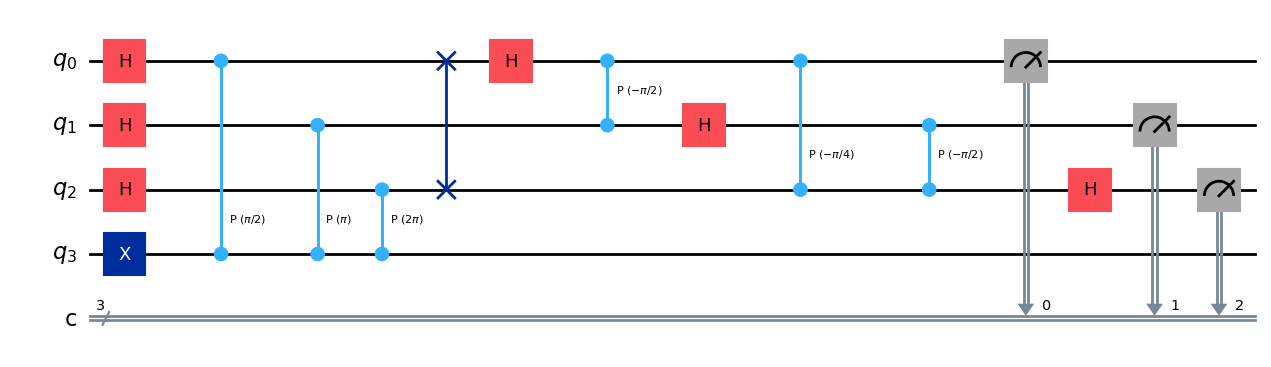


Phase θ = 0.375


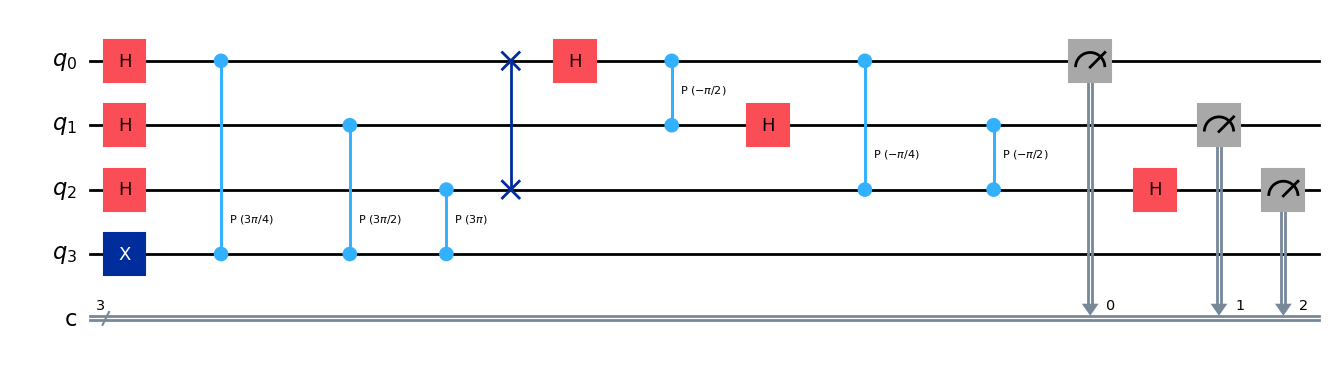


Phase θ = 0.5


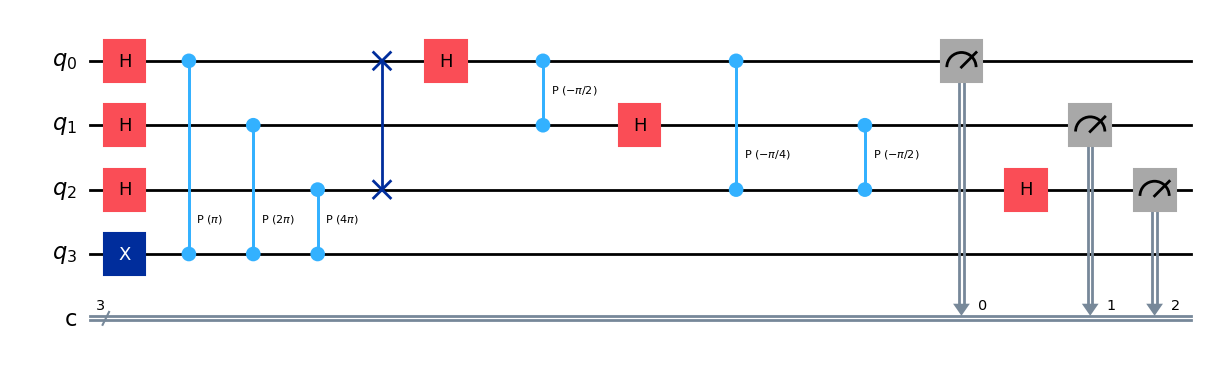


=== 🧩 Task 2 — Increase Counting Qubits ===

Using 3 counting qubits for θ = 0.375


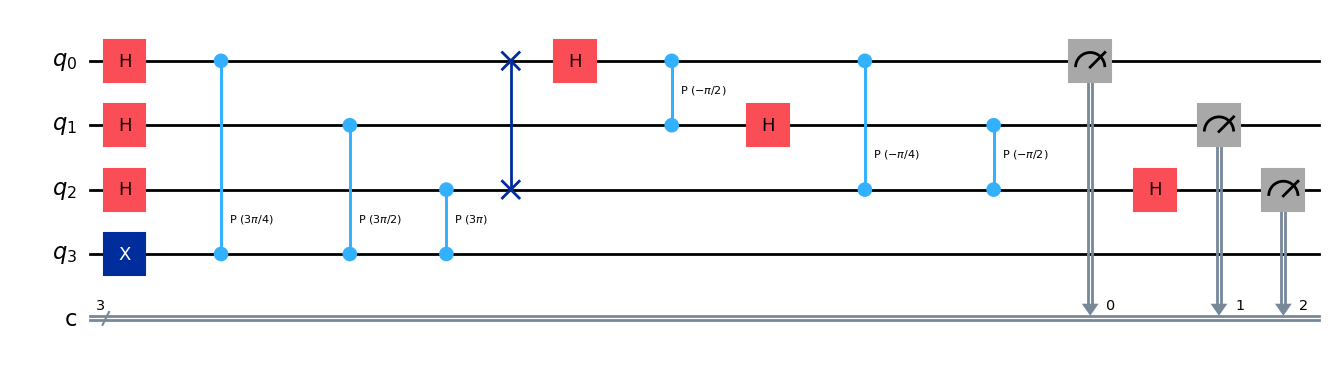


Using 4 counting qubits for θ = 0.375


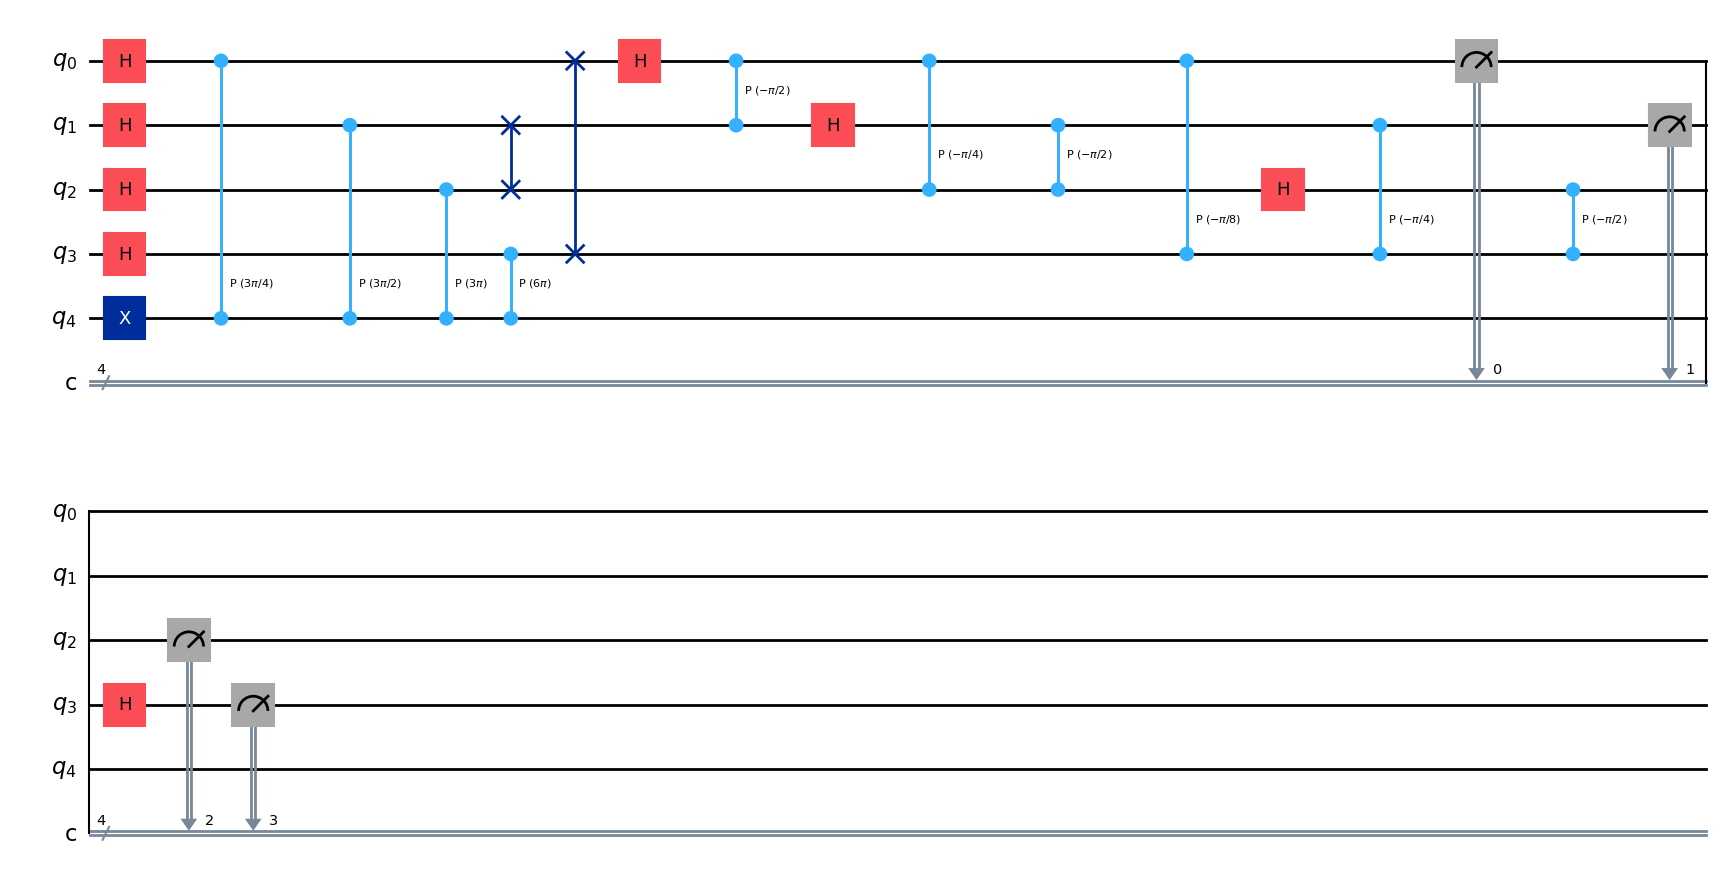


Using 5 counting qubits for θ = 0.375


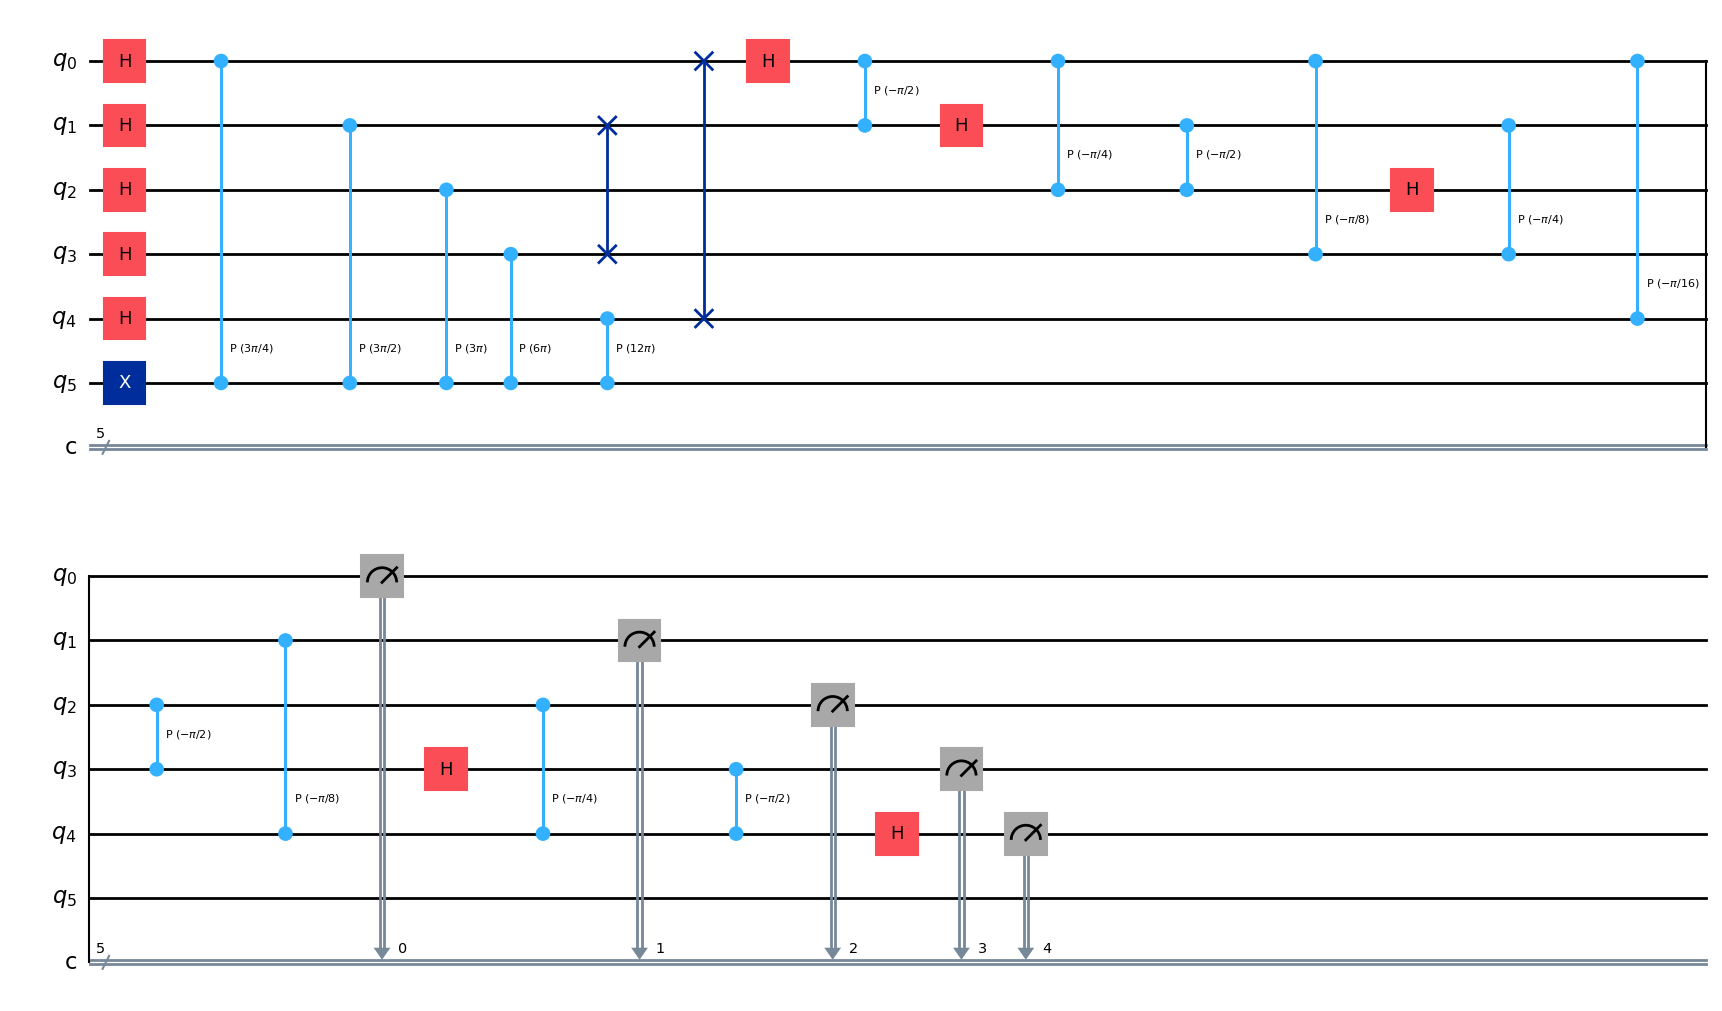


=== 🧩 Combined Task 3 & 4 — Phase Variation + Inverse QFT Visualization ===

--- Running QPE for θ = 0.25 ---

🔹 Inverse QFT Circuit Structure:


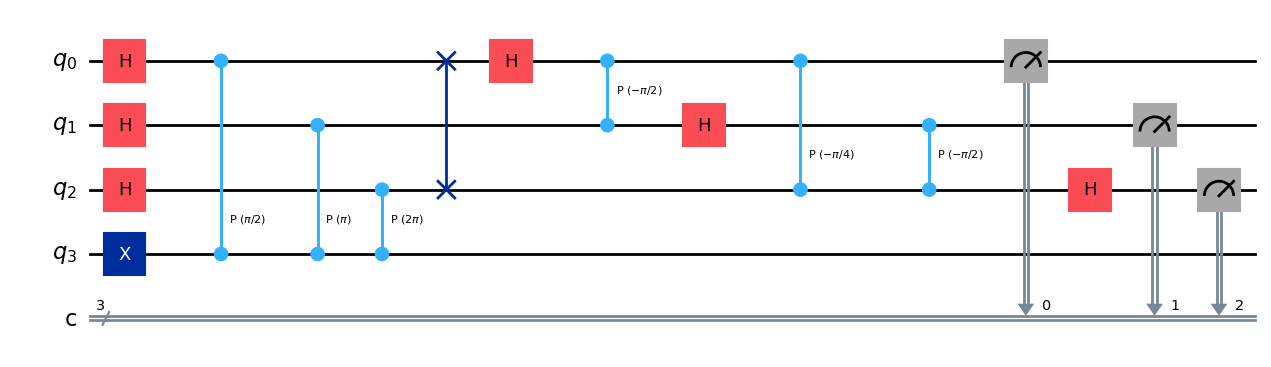

Expected Binary Output: 010 (Phase ≈ 0.25)
Measured Counts: {'010': 1024}

--- Running QPE for θ = 0.375 ---

🔹 Inverse QFT Circuit Structure:


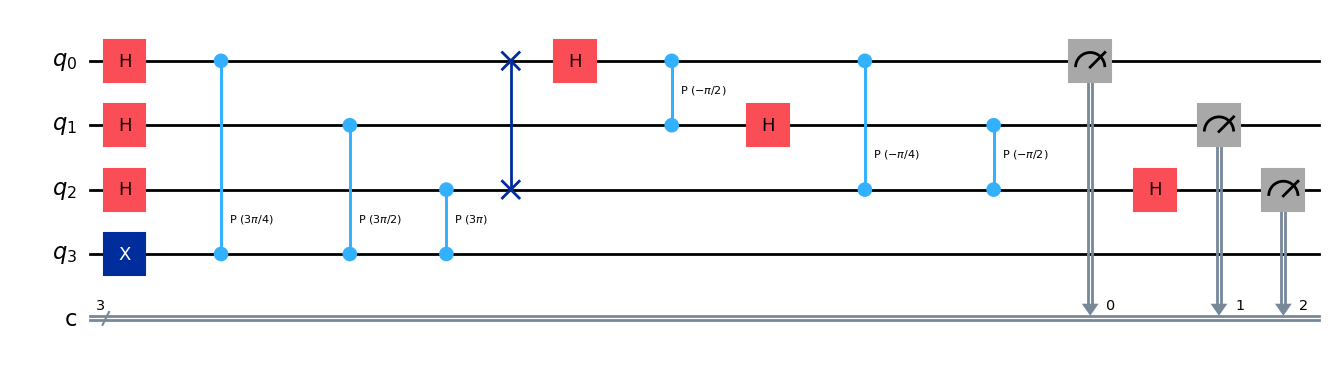

Expected Binary Output: 011 (Phase ≈ 0.375)
Measured Counts: {'011': 1024}

--- Running QPE for θ = 0.5 ---

🔹 Inverse QFT Circuit Structure:


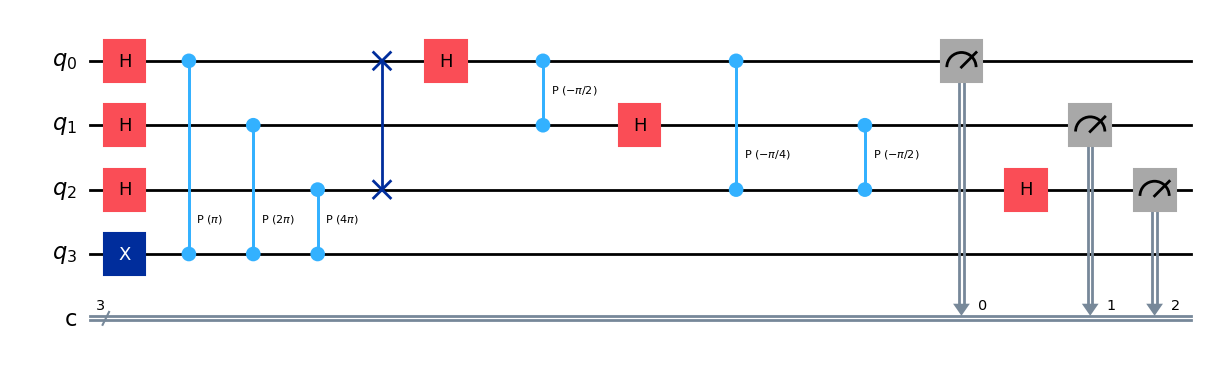

Expected Binary Output: 100 (Phase ≈ 0.5)
Measured Counts: {'100': 1024}

=== 🧩 Task 5 — Noise Simulation (Corrected) ===


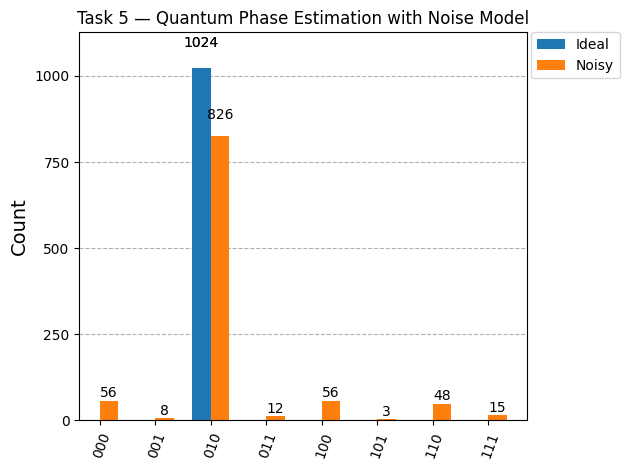

In [6]:
# ===============================================================
# 🧩 Quantum Phase Estimation (QPE) — All Student Tasks
# ===============================================================

!pip install -q qiskit qiskit-aer matplotlib pylatexenc

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# ⚙️ Helper — Inverse Quantum Fourier Transform (IQFT)
# ===============================================================
def inverse_qft(qc, n):
    """Applies inverse Quantum Fourier Transform on n qubits."""
    for j in range(n // 2):
        qc.swap(j, n - j - 1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi / float(2 ** (j - m)), m, j)
        qc.h(j)
    return qc


# ===============================================================
# ⚙️ Build QPE Circuit
# ===============================================================
def qpe_circuit(theta, n_count):
    """Creates Quantum Phase Estimation circuit estimating phase = theta."""
    qc = QuantumCircuit(n_count + 1, n_count)
    qc.h(range(n_count))        # counting qubits
    qc.x(n_count)               # eigenstate |1>
    for j in range(n_count):
        qc.cp(2 * np.pi * theta * (2 ** j), j, n_count)
    inverse_qft(qc, n_count)
    qc.measure(range(n_count), range(n_count))
    return qc


# ===============================================================
# 🧩 Task 1 — Change the Phase Value
# ===============================================================
print("=== 🧩 Task 1 — Change the Phase Value ===")

for theta in [0.25, 0.375, 0.5]:
    qc1 = qpe_circuit(theta, 3)
    print(f"\nPhase θ = {theta}")
    display(qc1.draw("mpl"))
    sim = AerSimulator()
    result = sim.run(transpile(qc1, sim), shots=1024).result()
    counts = result.get_counts()
    plot_histogram(counts, title=f"Task 1 — Measured Phase θ = {theta}")
plt.show()


# ===============================================================
# 🧩 Task 2 — Increase Counting Qubits (Precision)
# ===============================================================
print("\n=== 🧩 Task 2 — Increase Counting Qubits ===")

theta = 0.375
for n_count in [3, 4, 5]:
    qc2 = qpe_circuit(theta, n_count)
    print(f"\nUsing {n_count} counting qubits for θ = {theta}")
    display(qc2.draw("mpl"))
    sim = AerSimulator()
    counts = sim.run(transpile(qc2, sim), shots=1024).result().get_counts()
    plot_histogram(counts, title=f"Task 2 — n = {n_count} Counting Qubits")
plt.show()


# ===============================================================
# 🧩 Combined Task 3 & 4 — Phase Variation + Inverse QFT Visualization
# ===============================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Helper functions
# ----------------------------

def qft_rotations(qc, n):
    """Apply QFT rotations recursively."""
    if n == 0:
        return qc
    n -= 1
    qc.h(n)
    for qubit in range(n):
        qc.cp(np.pi / 2 ** (n - qubit), qubit, n)
    qft_rotations(qc, n)
    return qc

def swap_registers(qc, n):
    """Swap qubits to reverse order."""
    for qubit in range(n // 2):
        qc.swap(qubit, n - qubit - 1)
    return qc

def inverse_qft(qc, n):
    """Apply the inverse QFT."""
    swap_registers(qc, n)
    for qubit in range(n):
        for k in range(qubit):
            qc.cp(-np.pi / 2 ** (qubit - k), k, qubit)
        qc.h(qubit)
    return qc

def qpe_circuit(theta, n_count):
    """Build Quantum Phase Estimation circuit."""
    qc = QuantumCircuit(n_count + 1, n_count)

    # Step 1: Prepare |1⟩ eigenstate
    qc.x(n_count)

    # Step 2: Apply Hadamard to counting qubits
    qc.h(range(n_count))

    # Step 3: Apply controlled unitary rotations
    for qubit in range(n_count):
        qc.cp(2 * np.pi * theta * (2 ** qubit), qubit, n_count)

    # Step 4: Apply inverse QFT
    inverse_qft(qc, n_count)

    # Step 5: Measure counting qubits
    qc.measure(range(n_count), range(n_count))

    return qc

# ===============================================================
# 🧩 Combined Execution — Multiple Phase Values with Visualization
# ===============================================================
print("\n=== 🧩 Combined Task 3 & 4 — Phase Variation + Inverse QFT Visualization ===")

phases = [0.25, 0.375, 0.5]   # Different θ values
n_count = 3                   # Counting qubits

sim = AerSimulator()

for theta in phases:
    print(f"\n--- Running QPE for θ = {theta} ---")

    # Create QPE circuit
    qc = qpe_circuit(theta, n_count)

    # Visualize circuit before running
    print("\n🔹 Inverse QFT Circuit Structure:")
    display(qc.draw('mpl'))

    # Simulate execution
    compiled = transpile(qc, sim)
    result = sim.run(compiled, shots=1024).result()
    counts = result.get_counts()

    # Theoretical expected phase
    expected_phase = int(theta * (2 ** n_count))
    expected_binary = format(expected_phase, f"0{n_count}b")

    print(f"Expected Binary Output: {expected_binary} (Phase ≈ {theta})")
    print("Measured Counts:", counts)

    # Plot histogram
    plot_histogram(counts, title=f"QPE Results for θ = {theta}")
    plt.show()



# ===============================================================
# 🧩 Task 5 — Noise Simulation (Fixed Version)
# ===============================================================
print("\n=== 🧩 Task 5 — Noise Simulation (Corrected) ===")

theta = 0.25
n_count = 3
qc5 = qpe_circuit(theta, n_count)

# ✅ Define depolarizing noise correctly
noise_model = NoiseModel()

# 1-qubit gates (Hadamard, X)
error_1q = depolarizing_error(0.02, 1)

# 2-qubit gates (controlled-phase, CX)
error_2q = depolarizing_error(0.05, 2)

# Add to noise model
noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cp', 'cx'])

# ✅ Simulators
sim_ideal = AerSimulator()
sim_noisy = AerSimulator(noise_model=noise_model)

# ✅ Run both simulations
compiled_ideal = transpile(qc5, sim_ideal)
compiled_noisy = transpile(qc5, sim_noisy)

res_ideal = sim_ideal.run(compiled_ideal, shots=1024).result()
res_noisy = sim_noisy.run(compiled_noisy, shots=1024).result()

counts_ideal = res_ideal.get_counts()
counts_noisy = res_noisy.get_counts()

# ✅ Plot comparison
plot_histogram([counts_ideal, counts_noisy],
               legend=["Ideal", "Noisy"],
               title="Task 5 — Quantum Phase Estimation with Noise Model")
